# 14 — Prototype v1: Spline + Boosting Residual on FPS Coreset

**Direction:** spline_tuned backbone (FPS coreset, 395k per fold) + per-target CatBoost residual stage.

**Hypotheses (pre-specified):**
- **H1 (headline):** pooled R² ≥ 0.625 (beats FPS+spline baseline 0.6221 by ≥ 0.003).
- **H2:** ethylene R² gain > methane R² gain.
- **H3:** fold-1 ethylene R² improves by ≥ 0.05 vs spline-only.
- **H4:** swapping residual coreset (FPS → stratified at same budget) shifts pooled R² by ≤ 0.005.

**Protocol (inherits Stages 06–13):**
- 5 rolling temporal folds, same `validation_splits.parquet`, val slices unchanged.
- Fresh `RobustScaler` per fold, fit on the spline coreset.
- All hyperparameters frozen from Stage 11. No new tuning.
- CatBoost residual: per-target, last 15% of training data as eval_set, patience=50.

**Variants:** V0 (baseline) · V1 (primary) · V2 · V3 · V4 · Sanity.
**Runtime estimate:** ~20–30 min CPU.

In [1]:
import time
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import joblib

from sklearn.preprocessing import RobustScaler, SplineTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor

warnings.filterwarnings('ignore', category=UserWarning)

SEED = 42

DATA_PATH   = Path('../data/processed/ethylene_methane.parquet')
SPLITS_PATH = Path('../results/tables/validation_splits.parquet')
SUBSET_DIR  = Path('../data/subsets')
MODEL_DIR   = Path('../results/models/prototype_14')
TABLES_DIR  = Path('../results/tables')
FIG_DIR     = Path('../results/figures')
MEMO_PATH   = Path('../results/memos/14_prototype_v1.md')

for d in (MODEL_DIR, TABLES_DIR, FIG_DIR, MEMO_PATH.parent):
    d.mkdir(parents=True, exist_ok=True)

SENSORS = [f's{i:02d}' for i in range(1, 17)]
TARGETS = ['methane_ppm', 'ethylene_ppm']

# Variants: (name, backbone_coreset, residual_model, residual_coreset)
VARIANTS = [
    ('V0_spline_only',           'fps_395k', None,         None),
    ('V1_spline_cat_fps395k',    'fps_395k', 'catboost',   'fps_395k'),
    ('V2_spline_cat_fps25k',     'fps_395k', 'catboost',   'fps_25k'),
    ('V3_spline_et_fps60k',      'fps_395k', 'extratrees', 'fps_60k'),
    ('V4_spline_cat_strat395k',  'fps_395k', 'catboost',   'stratified_395k'),
    ('Sanity_cat_only_fps25k',   None,       'catboost',   'fps_25k'),
]

plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})
print(f'Variants: {len(VARIANTS)}')
for v in VARIANTS:
    print(f'  {v[0]:<28} backbone={v[1]}  residual={v[2]}@{v[3]}')

Variants: 6
  V0_spline_only               backbone=fps_395k  residual=None@None
  V1_spline_cat_fps395k        backbone=fps_395k  residual=catboost@fps_395k
  V2_spline_cat_fps25k         backbone=fps_395k  residual=catboost@fps_25k
  V3_spline_et_fps60k          backbone=fps_395k  residual=extratrees@fps_60k
  V4_spline_cat_strat395k      backbone=fps_395k  residual=catboost@stratified_395k
  Sanity_cat_only_fps25k       backbone=None  residual=catboost@fps_25k


## 1. Load Data, Splits, Caches, References

In [2]:
df = pd.read_parquet(DATA_PATH, columns=SENSORS + TARGETS)
splits_df = pd.read_parquet(SPLITS_PATH)
fold_ids = sorted(int(f) for f in splits_df['fold'].unique())

# Cache val slice per fold (loaded once)
val_cache = {}
for fold_id in fold_ids:
    va = splits_df[(splits_df['fold'] == fold_id) & (splits_df['split'] == 'val')].iloc[0]
    val_idx = np.arange(int(va['start_idx']), int(va['end_idx']))
    val_cache[fold_id] = {
        'X_va': df[SENSORS].iloc[val_idx].to_numpy(),
        'y_va': df[TARGETS].iloc[val_idx].to_numpy(),
        'val_start': int(va['start_idx']),
        'val_end':   int(va['end_idx']),
    }
    print(f'Fold {fold_id} val cached: {val_cache[fold_id]["X_va"].shape}')

# Reference numbers
print('\nReference R² (pooled):')
print('  Stage 13 spline+FPS@395k (V0 equivalent): 0.6221')
print('  Stage 13 catboost+FPS@25k (Sanity equiv): 0.5275')

Fold 1 val cached: (407367, 16)
Fold 2 val cached: (419449, 16)
Fold 3 val cached: (407362, 16)
Fold 4 val cached: (431972, 16)
Fold 5 val cached: (435098, 16)

Reference R² (pooled):
  Stage 13 spline+FPS@395k (V0 equivalent): 0.6221
  Stage 13 catboost+FPS@25k (Sanity equiv): 0.5275


## 2. Utilities

Coreset loader + temporal carve. Coresets are loaded from Stage 12 artifacts using the naming scheme `coreset_{label}_fold{k}.parquet`.

In [3]:
def load_coreset_idx(label, fold_id):
    # label examples: 'fps_395k', 'fps_25k', 'stratified_395k'
    method, budget_label = label.rsplit('_', 1)
    p = SUBSET_DIR / f'coreset_{method}_{budget_label}_fold{fold_id}.parquet'
    return pd.read_parquet(p, columns=['row_idx'])['row_idx'].to_numpy()

def prepare_X_y(coreset_idx, fold_id, scaler=None):
    v_lo = val_cache[fold_id]['val_start']
    v_hi = val_cache[fold_id]['val_end']
    assert not ((coreset_idx >= v_lo) & (coreset_idx < v_hi)).any(),         f'Coreset for fold {fold_id} contains own-fold val rows'
    X_tr = df[SENSORS].iloc[coreset_idx].to_numpy()
    y_tr = df[TARGETS].iloc[coreset_idx].to_numpy()
    if scaler is None:
        scaler = RobustScaler().fit(X_tr)
    return scaler.transform(X_tr), y_tr, scaler

def temporal_carve(X, y, frac=0.15):
    n = int(len(X) * (1 - frac))
    return X[:n], y[:n], X[n:], y[n:]

print('Utilities defined.')

Utilities defined.


## 3. Frozen Stage 11 Model Factories

In [4]:
def make_spline_tuned():
    return Pipeline([
        ('spline', SplineTransformer(n_knots=5, degree=3, include_bias=False)),
        ('ridge',  Ridge(alpha=1.0, random_state=SEED)),
    ])

def make_catboost_tuned():
    return CatBoostRegressor(
        iterations=2000, learning_rate=0.05, depth=6, l2_leaf_reg=10,
        border_count=32, random_seed=SEED, verbose=0, thread_count=-1,
    )

def make_extratrees_tuned():
    return ExtraTreesRegressor(
        n_estimators=200, max_depth=10, min_samples_leaf=50,
        max_features='sqrt', n_jobs=-1, random_state=SEED,
    )

def fit_per_target_boosted(model_name, X_tr_s, y_tr, frac_eval=0.15):
    if model_name == 'catboost':
        X_main, y_main, X_eval, y_eval = temporal_carve(X_tr_s, y_tr, frac=frac_eval)
        models = {}
        for t_idx, target in enumerate(TARGETS):
            m = make_catboost_tuned()
            m.fit(X_main, y_main[:, t_idx],
                  eval_set=(X_eval, y_eval[:, t_idx]),
                  early_stopping_rounds=50)
            models[target] = m
        return models
    elif model_name == 'extratrees':
        # ExtraTrees has no early stopping; native multi-output via single fit
        m = make_extratrees_tuned()
        m.fit(X_tr_s, y_tr)
        return {'native_multi_output': m}
    else:
        raise ValueError(f'Unknown residual model: {model_name}')

def predict_per_target_boosted(model_name, models, X_va_s):
    if model_name == 'catboost':
        y_pred = np.zeros((len(X_va_s), 2))
        for t_idx, target in enumerate(TARGETS):
            y_pred[:, t_idx] = models[target].predict(X_va_s)
        return y_pred
    elif model_name == 'extratrees':
        return models['native_multi_output'].predict(X_va_s)

print('Factories defined.')

Factories defined.


## 4. Hybrid Fit/Predict — variants

In [5]:
def run_variant(variant_name, backbone_coreset, residual_model, residual_coreset, fold_id, save=False):
    """Returns (y_pred, n_train_rows, fit_seconds) for the variant on the fold."""
    t0 = time.perf_counter()
    val_X = val_cache[fold_id]['X_va']
    val_y = val_cache[fold_id]['y_va']

    if backbone_coreset is None:
        # Sanity variant: residual model trained on raw y (i.e., direct prediction)
        coreset_idx = load_coreset_idx(residual_coreset, fold_id)
        X_tr_s, y_tr, scaler = prepare_X_y(coreset_idx, fold_id)
        X_va_s = scaler.transform(val_X)
        models = fit_per_target_boosted(residual_model, X_tr_s, y_tr)
        y_pred = predict_per_target_boosted(residual_model, models, X_va_s)
        artifacts = {'scaler': scaler, 'residual_models': models, 'spline': None}
    else:
        # Backbone: spline on backbone coreset
        b_idx = load_coreset_idx(backbone_coreset, fold_id)
        X_b_s, y_b, scaler = prepare_X_y(b_idx, fold_id)
        X_va_s = scaler.transform(val_X)
        spline = make_spline_tuned()
        spline.fit(X_b_s, y_b)
        spline_val_pred = spline.predict(X_va_s)

        if residual_model is None:
            y_pred = spline_val_pred
            artifacts = {'scaler': scaler, 'residual_models': None, 'spline': spline}
        else:
            # Residual stage: train on residual_coreset (same scaler)
            r_idx = load_coreset_idx(residual_coreset, fold_id)
            X_r = df[SENSORS].iloc[r_idx].to_numpy()
            y_r = df[TARGETS].iloc[r_idx].to_numpy()
            X_r_s = scaler.transform(X_r)
            r_spline_pred = spline.predict(X_r_s)
            r_train = y_r - r_spline_pred  # residuals on the residual coreset
            models = fit_per_target_boosted(residual_model, X_r_s, r_train)
            r_val_pred = predict_per_target_boosted(residual_model, models, X_va_s)
            y_pred = spline_val_pred + r_val_pred
            artifacts = {'scaler': scaler, 'residual_models': models, 'spline': spline}

    elapsed = time.perf_counter() - t0
    n_train = int(len(load_coreset_idx(residual_coreset if backbone_coreset is None else backbone_coreset, fold_id)))

    if save:
        out = MODEL_DIR / f'fold_{fold_id}_{variant_name}.joblib'
        joblib.dump({'variant': variant_name, 'fold': fold_id, **artifacts}, out)

    return y_pred, n_train, elapsed

print('Hybrid runner defined.')

Hybrid runner defined.


## 5. Run All Variants × Folds

In [6]:
records = []
t_total = time.perf_counter()
for variant_name, backbone, resid_model, resid_coreset in VARIANTS:
    save_models = variant_name.startswith('V1_')
    print(f'\n=== {variant_name} ===  (save_models={save_models})')
    for fold_id in fold_ids:
        val_y = val_cache[fold_id]['y_va']
        y_pred, n_train, elapsed = run_variant(
            variant_name, backbone, resid_model, resid_coreset, fold_id,
            save=save_models,
        )
        for t_idx, target in enumerate(TARGETS):
            records.append({
                'variant': variant_name,
                'backbone_coreset': backbone or '(none)',
                'residual_model': resid_model or '(none)',
                'residual_coreset': resid_coreset or '(none)',
                'fold': fold_id, 'target': target,
                'mae':  float(mean_absolute_error(val_y[:, t_idx], y_pred[:, t_idx])),
                'rmse': float(np.sqrt(mean_squared_error(val_y[:, t_idx], y_pred[:, t_idx]))),
                'r2':   float(r2_score(val_y[:, t_idx], y_pred[:, t_idx])),
                'n_train_rows': n_train,
                'seconds': elapsed,
            })
        print(f'  fold {fold_id}: {elapsed:5.1f}s  '
              f'R²(meth)={records[-2]["r2"]:.4f}  R²(eth)={records[-1]["r2"]:.4f}')

print(f'\nTotal: {time.perf_counter()-t_total:.0f}s '
      f'({(time.perf_counter()-t_total)/60:.1f} min)')
print(f'Records: {len(records)} (expect {len(VARIANTS)*5*2} = {len(VARIANTS)*10})')
assert len(records) == len(VARIANTS) * 10


=== V0_spline_only ===  (save_models=False)
  fold 1:   2.8s  R²(meth)=0.7261  R²(eth)=0.4979
  fold 2:   2.5s  R²(meth)=0.6227  R²(eth)=0.7582
  fold 3:   2.4s  R²(meth)=0.6223  R²(eth)=0.5458
  fold 4:   2.6s  R²(meth)=0.6542  R²(eth)=0.5416
  fold 5:   2.6s  R²(meth)=0.6697  R²(eth)=0.5825

=== V1_spline_cat_fps395k ===  (save_models=True)
  fold 1:   6.1s  R²(meth)=0.7251  R²(eth)=0.3635
  fold 2:   5.9s  R²(meth)=0.6224  R²(eth)=0.7583
  fold 3:   6.0s  R²(meth)=0.6234  R²(eth)=0.5445
  fold 4:   6.5s  R²(meth)=0.6269  R²(eth)=0.5431
  fold 5:   5.6s  R²(meth)=0.6703  R²(eth)=0.5828

=== V2_spline_cat_fps25k ===  (save_models=False)
  fold 1:   3.3s  R²(meth)=0.7251  R²(eth)=0.3399
  fold 2:   3.1s  R²(meth)=0.6221  R²(eth)=0.7596
  fold 3:   3.0s  R²(meth)=0.6227  R²(eth)=0.5457
  fold 4:   3.2s  R²(meth)=0.6431  R²(eth)=0.5429
  fold 5:   3.1s  R²(meth)=0.6721  R²(eth)=0.5832

=== V3_spline_et_fps60k ===  (save_models=False)
  fold 1:   3.3s  R²(meth)=0.7159  R²(eth)=0.4846
  f

## 6. Save Tables

In [7]:
long_df = pd.DataFrame(records)
long_path = TABLES_DIR / '14_prototype_metrics_long.parquet'
long_df.to_parquet(long_path, index=False)
print(f'Saved: {long_path}')

summary = (long_df.groupby(['variant', 'target'])[['mae', 'rmse', 'r2']]
           .agg(['mean', 'std']).round(4))
summary.columns = [f'{m}_{s}' for m, s in summary.columns]
summary = summary.reset_index()
summary_path = TABLES_DIR / '14_prototype_metrics_summary.parquet'
summary.to_parquet(summary_path, index=False)
print(f'Saved: {summary_path}')

pooled = (long_df.groupby('variant')['r2']
          .agg(['mean','std']).round(4).reset_index()
          .rename(columns={'mean':'pooled_r2_mean','std':'pooled_r2_std'})
          .sort_values('pooled_r2_mean', ascending=False))
print('\nPooled R² per variant (sorted):')
print(pooled.to_string(index=False))

Saved: ..\results\tables\14_prototype_metrics_long.parquet
Saved: ..\results\tables\14_prototype_metrics_summary.parquet

Pooled R² per variant (sorted):
                variant  pooled_r2_mean  pooled_r2_std
    V3_spline_et_fps60k          0.6236         0.0813
         V0_spline_only          0.6221         0.0829
  V1_spline_cat_fps395k          0.6060         0.1104
   V2_spline_cat_fps25k          0.6056         0.1169
V4_spline_cat_strat395k          0.5951         0.1272
 Sanity_cat_only_fps25k          0.5275         0.1230


## 7. Analysis A — Ingredient Attribution

V0 → V1: backbone + residual gain.
V1 → V4: coreset effect on residual (FPS vs stratified at same budget).
V1 vs V3: residual-model swap.

In [8]:
def pooled_r2(variant):
    return float(long_df[long_df['variant']==variant]['r2'].mean())

ablation_rows = []
ablation_rows.append({
    'analysis': 'A — backbone + residual gain',
    'comparison': 'V1 − V0',
    'delta_r2': round(pooled_r2('V1_spline_cat_fps395k') -
                      pooled_r2('V0_spline_only'), 4),
})
ablation_rows.append({
    'analysis': 'A — coreset effect on residual',
    'comparison': 'V1 − V4 (FPS − stratified residual)',
    'delta_r2': round(pooled_r2('V1_spline_cat_fps395k') -
                      pooled_r2('V4_spline_cat_strat395k'), 4),
})
ablation_rows.append({
    'analysis': 'A — residual budget effect',
    'comparison': 'V1 − V2 (395k − 25k residual)',
    'delta_r2': round(pooled_r2('V1_spline_cat_fps395k') -
                      pooled_r2('V2_spline_cat_fps25k'), 4),
})
ablation_rows.append({
    'analysis': 'D — residual-model swap',
    'comparison': 'V1 − V3 (CatBoost − ExtraTrees residual)',
    'delta_r2': round(pooled_r2('V1_spline_cat_fps395k') -
                      pooled_r2('V3_spline_et_fps60k'), 4),
})
abl_df = pd.DataFrame(ablation_rows)
abl_path = TABLES_DIR / '14_prototype_ablation.parquet'
abl_df.to_parquet(abl_path, index=False)
print(f'Saved: {abl_path}')
print(abl_df.to_string(index=False))

Saved: ..\results\tables\14_prototype_ablation.parquet
                      analysis                               comparison  delta_r2
  A — backbone + residual gain                                  V1 − V0   -0.0160
A — coreset effect on residual      V1 − V4 (FPS − stratified residual)    0.0109
    A — residual budget effect            V1 − V2 (395k − 25k residual)    0.0004
       D — residual-model swap V1 − V3 (CatBoost − ExtraTrees residual)   -0.0176


## 8. Analysis B — Per-target Structure (H2)

Does ethylene gain more than methane?

In [9]:
def per_target_pooled(variant):
    sub = long_df[long_df['variant']==variant]
    return {
        'methane':  float(sub[sub['target']=='methane_ppm']['r2'].mean()),
        'ethylene': float(sub[sub['target']=='ethylene_ppm']['r2'].mean()),
    }

v0 = per_target_pooled('V0_spline_only')
v1 = per_target_pooled('V1_spline_cat_fps395k')
meth_gain = round(v1['methane']  - v0['methane'],  4)
eth_gain  = round(v1['ethylene'] - v0['ethylene'], 4)

print(f'V0 methane R²={v0["methane"]:.4f}  ethylene R²={v0["ethylene"]:.4f}')
print(f'V1 methane R²={v1["methane"]:.4f}  ethylene R²={v1["ethylene"]:.4f}')
print(f'Gain: methane {meth_gain:+.4f}  ethylene {eth_gain:+.4f}')
print()
h2_pass = eth_gain > meth_gain
print(f'H2 (ethylene gain > methane gain): {"PASS" if h2_pass else "FAIL"}')

V0 methane R²=0.6590  ethylene R²=0.5852
V1 methane R²=0.6536  ethylene R²=0.5585
Gain: methane -0.0054  ethylene -0.0267

H2 (ethylene gain > methane gain): FAIL


## 9. Analysis C — Per-fold Breakdown (H3)

Is fold-1 ethylene R² improved by ≥ 0.05?

In [10]:
per_fold = (long_df.pivot_table(index=['variant','fold'], columns='target', values='r2')
            .round(4))
per_fold_path = TABLES_DIR / '14_per_fold_breakdown.parquet'
per_fold.reset_index().to_parquet(per_fold_path, index=False)
print(f'Saved: {per_fold_path}')

v0_f1_eth = float(long_df[(long_df['variant']=='V0_spline_only') &
                          (long_df['fold']==1) &
                          (long_df['target']=='ethylene_ppm')]['r2'].iloc[0])
v1_f1_eth = float(long_df[(long_df['variant']=='V1_spline_cat_fps395k') &
                          (long_df['fold']==1) &
                          (long_df['target']=='ethylene_ppm')]['r2'].iloc[0])
fold1_eth_gain = round(v1_f1_eth - v0_f1_eth, 4)
print(f'\nFold-1 ethylene R²:  V0={v0_f1_eth:.4f}  V1={v1_f1_eth:.4f}  gain={fold1_eth_gain:+.4f}')
h3_pass = fold1_eth_gain >= 0.05
print(f'H3 (fold-1 ethylene gain ≥ 0.05): {"PASS" if h3_pass else "FAIL"}')
print()
print('Per-variant per-fold ethylene R²:')
print(per_fold['ethylene_ppm'].unstack('fold').to_string())
print()
print('Per-variant per-fold methane R²:')
print(per_fold['methane_ppm'].unstack('fold').to_string())

Saved: ..\results\tables\14_per_fold_breakdown.parquet

Fold-1 ethylene R²:  V0=0.4979  V1=0.3635  gain=-0.1343
H3 (fold-1 ethylene gain ≥ 0.05): FAIL

Per-variant per-fold ethylene R²:
fold                          1       2       3       4       5
variant                                                        
Sanity_cat_only_fps25k   0.2552  0.5380  0.4782  0.4227  0.5112
V0_spline_only           0.4979  0.7582  0.5458  0.5416  0.5825
V1_spline_cat_fps395k    0.3635  0.7583  0.5445  0.5431  0.5828
V2_spline_cat_fps25k     0.3399  0.7596  0.5457  0.5429  0.5832
V3_spline_et_fps60k      0.4846  0.7326  0.5704  0.5208  0.6022
V4_spline_cat_strat395k  0.2938  0.7585  0.5366  0.5444  0.5822

Per-variant per-fold methane R²:
fold                          1       2       3       4       5
variant                                                        
Sanity_cat_only_fps25k   0.6845  0.5380  0.6050  0.6212  0.6205
V0_spline_only           0.7261  0.6227  0.6223  0.6542  0.6697
V1_spline_ca

## 10. Verdicts on H1–H4

In [11]:
v1_pooled = pooled_r2('V1_spline_cat_fps395k')
v0_pooled = pooled_r2('V0_spline_only')
v4_pooled = pooled_r2('V4_spline_cat_strat395k')

h1_pass = v1_pooled >= 0.625
h4_delta = abs(v1_pooled - v4_pooled)
h4_pass  = h4_delta <= 0.005

verdicts = pd.DataFrame([
    {'hypothesis': 'H1 (pooled R² ≥ 0.625)',
     'value':  round(v1_pooled, 4), 'threshold': 0.625,
     'verdict': 'PASS' if h1_pass else 'FAIL'},
    {'hypothesis': 'H2 (ethylene gain > methane gain)',
     'value':  f'meth {meth_gain:+.4f}, eth {eth_gain:+.4f}', 'threshold': 'eth > meth',
     'verdict': 'PASS' if h2_pass else 'FAIL'},
    {'hypothesis': 'H3 (fold-1 ethylene gain ≥ 0.05)',
     'value':  fold1_eth_gain, 'threshold': 0.05,
     'verdict': 'PASS' if h3_pass else 'FAIL'},
    {'hypothesis': 'H4 (|V1 − V4| ≤ 0.005)',
     'value':  round(h4_delta, 4), 'threshold': 0.005,
     'verdict': 'PASS' if h4_pass else 'FAIL'},
])
print(verdicts.to_string(index=False))
print()
print(f'V0 (baseline)            pooled R² = {v0_pooled:.4f}')
print(f'V1 (primary)             pooled R² = {v1_pooled:.4f}')
print(f'V4 (stratified residual) pooled R² = {v4_pooled:.4f}')
print(f'Stage 13 FPS+spline ref  pooled R² = 0.6221')
overall = 'GRADUATE to Task 4.1' if h1_pass else 'DO NOT graduate (consider regime-aware alternative)'
print(f'\nOverall recommendation: {overall}')

                       hypothesis                     value  threshold verdict
           H1 (pooled R² ≥ 0.625)                     0.606      0.625    FAIL
H2 (ethylene gain > methane gain) meth -0.0054, eth -0.0267 eth > meth    FAIL
 H3 (fold-1 ethylene gain ≥ 0.05)                   -0.1343       0.05    FAIL
           H4 (|V1 − V4| ≤ 0.005)                    0.0109      0.005    FAIL

V0 (baseline)            pooled R² = 0.6221
V1 (primary)             pooled R² = 0.6060
V4 (stratified residual) pooled R² = 0.5951
Stage 13 FPS+spline ref  pooled R² = 0.6221

Overall recommendation: DO NOT graduate (consider regime-aware alternative)


## 11. Figures

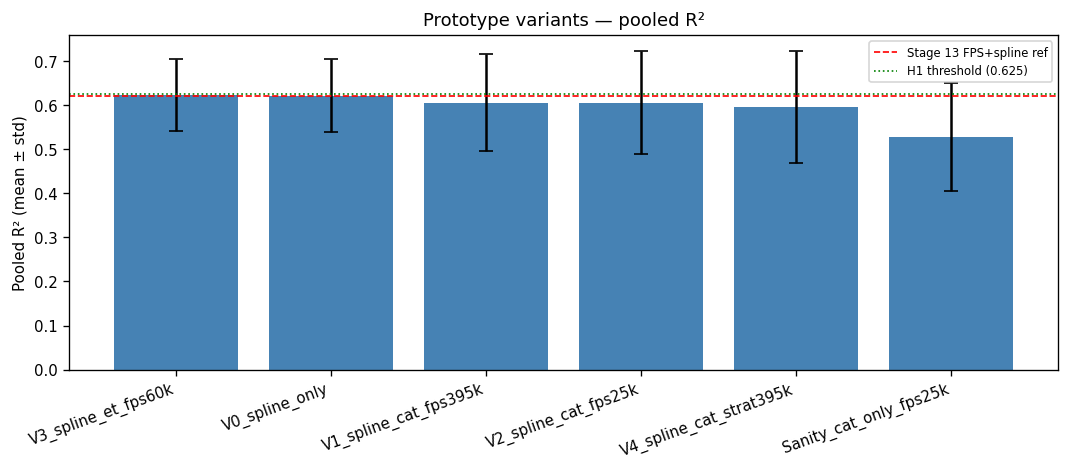

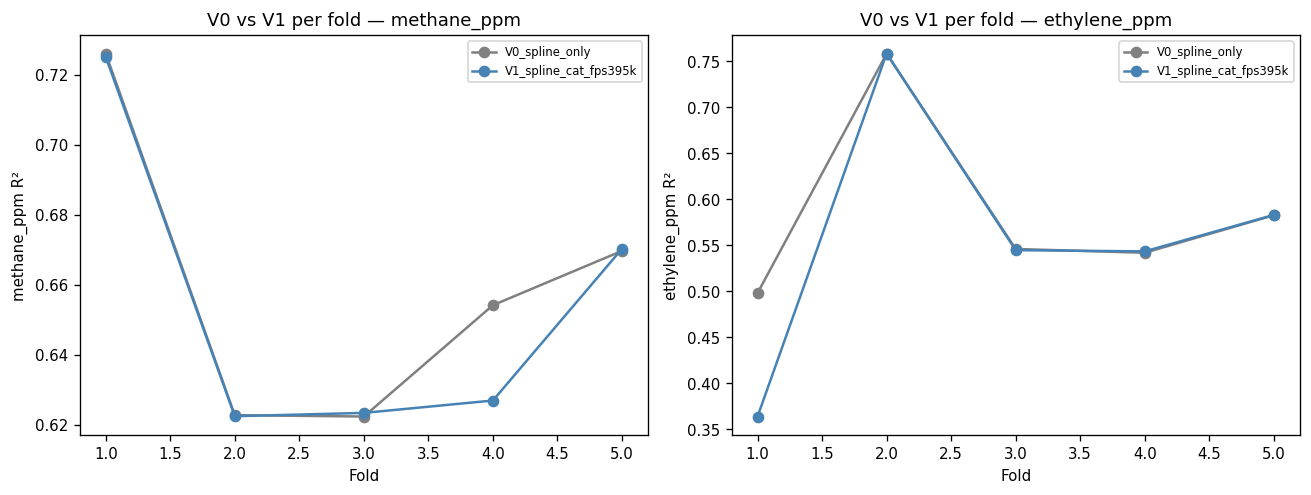

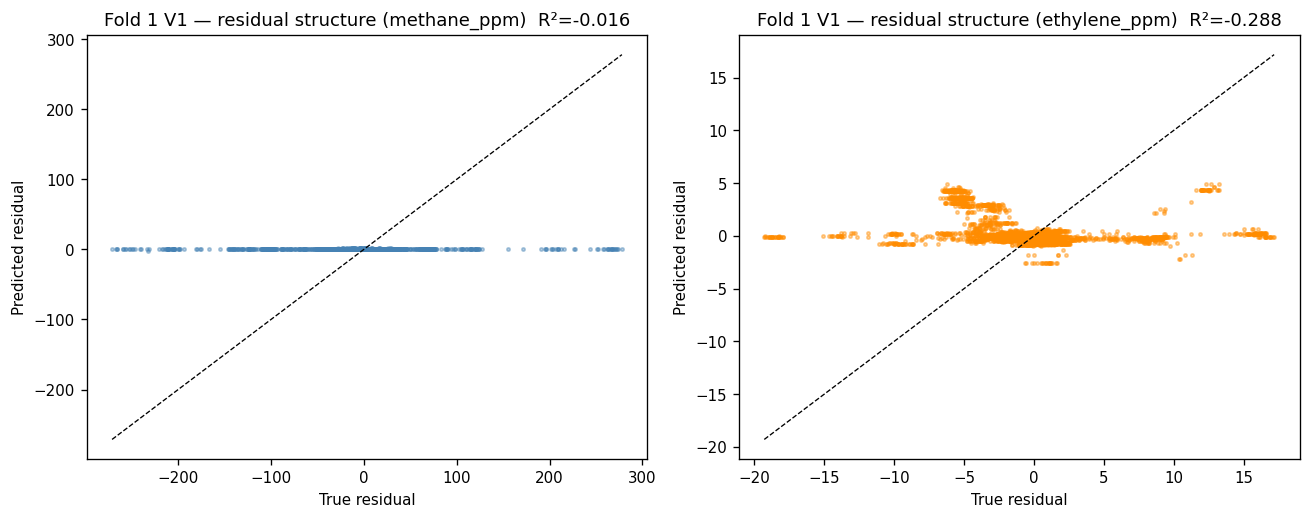

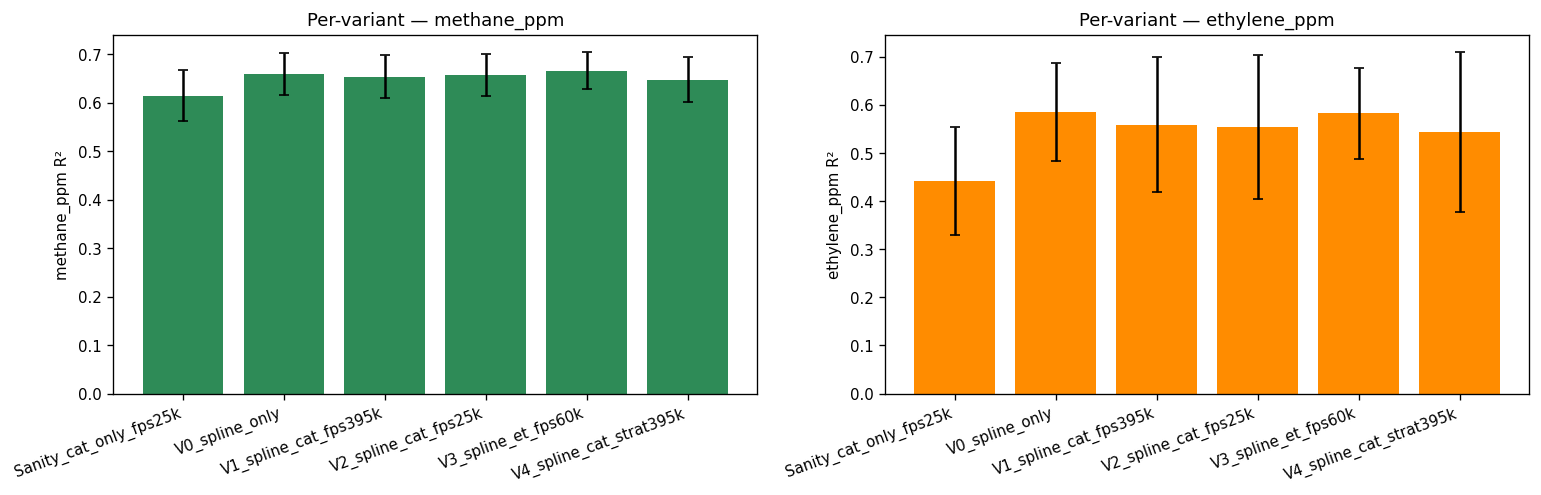

Saved 4 figures.


In [12]:
# Figure 1: pooled R² bars, 6 variants
fig, ax = plt.subplots(figsize=(9, 4))
order = pooled.sort_values('pooled_r2_mean', ascending=False)
ax.bar(order['variant'], order['pooled_r2_mean'],
       yerr=order['pooled_r2_std'], capsize=4, color='steelblue')
ax.axhline(0.6221, color='red', ls='--', lw=1.0, label='Stage 13 FPS+spline ref')
ax.axhline(0.625,  color='green', ls=':', lw=1.0, label='H1 threshold (0.625)')
ax.set_ylabel('Pooled R² (mean ± std)')
ax.set_title('Prototype variants — pooled R²')
plt.xticks(rotation=20, ha='right')
ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(FIG_DIR / '14_prototype_vs_baselines.png', bbox_inches='tight')
plt.show()

# Figure 2: per-fold R² for V0 vs V1, 2 targets
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, target in zip(axes, TARGETS):
    for variant, color in [('V0_spline_only','gray'),
                           ('V1_spline_cat_fps395k','steelblue')]:
        sub = long_df[(long_df['variant']==variant) & (long_df['target']==target)]
        ax.plot(sub['fold'], sub['r2'], 'o-', label=variant, color=color)
    ax.set_xlabel('Fold')
    ax.set_ylabel(f'{target} R²')
    ax.set_title(f'V0 vs V1 per fold — {target}')
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(FIG_DIR / '14_per_fold_comparison.png', bbox_inches='tight')
plt.show()

# Figure 3: residual structure (fold 1, V1) — true vs predicted residual
art = joblib.load(MODEL_DIR / 'fold_1_V1_spline_cat_fps395k.joblib')
scaler = art['scaler']; spline = art['spline']; resid_models = art['residual_models']
val_X1 = val_cache[1]['X_va']; val_y1 = val_cache[1]['y_va']
val_X1_s = scaler.transform(val_X1)
spline_pred = spline.predict(val_X1_s)
true_resid = val_y1 - spline_pred
pred_resid = np.column_stack([resid_models[t].predict(val_X1_s) for t in TARGETS])

n_plot = min(5000, len(val_y1))
samp = np.random.default_rng(SEED).choice(len(val_y1), n_plot, replace=False)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, t_idx, target, color in zip(axes, (0,1), TARGETS, ('steelblue','darkorange')):
    a = true_resid[samp, t_idx]
    p = pred_resid[samp, t_idx]
    ax.scatter(a, p, s=4, alpha=0.4, color=color)
    lo = float(min(a.min(), p.min())); hi = float(max(a.max(), p.max()))
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8)
    ax.set_xlabel('True residual'); ax.set_ylabel('Predicted residual')
    rsq = float(r2_score(a, p))
    ax.set_title(f'Fold 1 V1 — residual structure ({target})  R²={rsq:.3f}')
plt.tight_layout()
plt.savefig(FIG_DIR / '14_residual_structure.png', bbox_inches='tight')
plt.show()

# Figure 4: per-target bars per variant
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=False)
for ax, target in zip(axes, TARGETS):
    sub = (long_df[long_df['target']==target]
           .groupby('variant')['r2'].agg(['mean','std']).reset_index())
    ax.bar(sub['variant'], sub['mean'], yerr=sub['std'], capsize=3,
           color='seagreen' if target=='methane_ppm' else 'darkorange')
    ax.set_ylabel(f'{target} R²')
    ax.set_title(f'Per-variant — {target}')
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / '14_per_target_breakdown.png', bbox_inches='tight')
plt.show()

print('Saved 4 figures.')

## 12. Memo

In [13]:
def df_to_md(t):
    header = '| ' + ' | '.join(str(c) for c in t.columns) + ' |'
    sep    = '| ' + ' | '.join(['---'] * len(t.columns)) + ' |'
    rows   = ['| ' + ' | '.join(str(v) for v in row) + ' |'
              for row in t.itertuples(index=False)]
    return '\n'.join([header, sep, *rows])

lines = [
    '# 14 - Prototype v1: Spline + Boosting Residual on FPS Coreset',
    '',
    '**Date:** 2026-05-29',
    f'**Dataset:** {DATA_PATH.as_posix()}',
    f'**Splits artifact:** {SPLITS_PATH.as_posix()}',
    '',
    '---',
    '',
    '## Direction',
    'Two-stage hybrid: spline_tuned backbone trained on FPS 395k coreset + per-target CatBoost residual stage. Frozen Stage 11 configs.',
    '',
    '## Hypotheses (pre-specified)',
    '- **H1:** pooled R² >= 0.625.',
    '- **H2:** ethylene R² gain > methane R² gain over spline-only.',
    '- **H3:** fold-1 ethylene R² improves by >= 0.05 vs spline-only.',
    '- **H4:** |V1 - V4| <= 0.005.',
    '',
    '## Variants',
    '',
    df_to_md(pd.DataFrame([
        {'variant':'V0_spline_only','backbone':'fps_395k','residual':'(none)','resid_coreset':'(none)'},
        {'variant':'V1_spline_cat_fps395k','backbone':'fps_395k','residual':'catboost','resid_coreset':'fps_395k'},
        {'variant':'V2_spline_cat_fps25k','backbone':'fps_395k','residual':'catboost','resid_coreset':'fps_25k'},
        {'variant':'V3_spline_et_fps60k','backbone':'fps_395k','residual':'extratrees','resid_coreset':'fps_60k'},
        {'variant':'V4_spline_cat_strat395k','backbone':'fps_395k','residual':'catboost','resid_coreset':'stratified_395k'},
        {'variant':'Sanity_cat_only_fps25k','backbone':'(none)','residual':'catboost','resid_coreset':'fps_25k'},
    ])),
    '',
    '## Pooled R² by Variant',
    '',
    df_to_md(pooled.round(4)),
    '',
    '## Analysis A — Ingredient Attribution',
    '',
    df_to_md(abl_df),
    '',
    '## Verdicts on H1-H4',
    '',
    df_to_md(verdicts),
    '',
    f'**Overall recommendation:** {overall}',
    '',
    '## Artifacts',
    f'- Long records: `{long_path.as_posix()}`',
    f'- Summary: `{summary_path.as_posix()}`',
    f'- Ablation: `{abl_path.as_posix()}`',
    f'- Per-fold breakdown: `{per_fold_path.as_posix()}`',
    f'- Models (V1 only): `{MODEL_DIR.as_posix()}/fold_{{k}}_V1_spline_cat_fps395k.joblib`',
    f'- Figures: `{FIG_DIR.as_posix()}/14_{{prototype_vs_baselines,per_fold_comparison,residual_structure,per_target_breakdown}}.png`',
    '',
    '## Next step',
    '',
    'If H1 passed: Task 4.1 graduates V1 to the final prototype slot. Proceed to Task 4.2 interpretation (already preempted by Analyses A-C here).',
    '',
    'If H1 failed: revisit Task 3.3 archetype choice. The regime-aware alternative (deferred) becomes the next candidate.',
]

MEMO_PATH.write_text('\n'.join(lines), encoding='utf-8')
print(f'Memo saved to {MEMO_PATH}')

Memo saved to ..\results\memos\14_prototype_v1.md
